# Credix - exp_analysis.ipynb

Notebook de análise exploratória, explicabilidade e monitoramento. O objetivo é gerar gráficos para os slides do TCC Lab FIA: perfil da base, desbalanceamento, correlações, SHAP e PSI.

In [61]:
# ============================================================
# Configuração inicial do projeto Credix
# ============================================================

import os
import sys
import json
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Descobre a raiz do projeto mesmo se o notebook estiver dentro de /notebooks
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() in ["notebooks", "model", "models"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
GOLD_DIR = PROJECT_ROOT / "gold"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("GOLD_DIR:", GOLD_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix
GOLD_DIR: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\gold
MODELS_DIR: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\models
FIGURES_DIR: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures


In [62]:
# ============================================================
# Carregar ABT final do projeto Credix
# ============================================================

ABT_PATH = PROJECT_ROOT / "gold" / "abt.csv"

df = pd.read_csv(ABT_PATH)

print("ABT carregada de:", ABT_PATH)
print("Shape da ABT:", df.shape)

print("\nPrimeiras colunas:")
print(df.columns.tolist()[:30])

print("\nDistribuição do TARGET:")
display(
    df["TARGET"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("percentual")
)

display(df.head())

ABT carregada de: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\gold\abt.csv
Shape da ABT: (307511, 21)

Primeiras colunas:
['SK_ID_CURR', 'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'IDADE', 'TEMPO_EMPRESA', 'CREDITO_RENDA', 'PARCELA_RENDA', 'BEM_RENDA', 'RENDA_LIVRE', 'COMPROMETIMENTO_RENDA', 'PRAZO_ESTIMADO', 'BUREAU_QTD_CREDITOS', 'BUREAU_QTD_ATIVOS', 'BUREAU_TOTAL_CREDITO', 'BUREAU_TOTAL_DIVIDA', 'BUREAU_DEBT_RATIO']

Distribuição do TARGET:


,percentual
TARGET,
0,91.93
1,8.07


,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,IDADE,TEMPO_EMPRESA,...,PARCELA_RENDA,BEM_RENDA,RENDA_LIVRE,COMPROMETIMENTO_RENDA,PRAZO_ESTIMADO,BUREAU_QTD_CREDITOS,BUREAU_QTD_ATIVOS,BUREAU_TOTAL_CREDITO,BUREAU_TOTAL_DIVIDA,BUREAU_DEBT_RATIO
0,100002,1,202500.0,406597.5,24700.5,351000.0,Secondary / secondary special,Single / not married,25.92,1.75,...,0.12,1.73,177799.5,0.12,16.46,8.0,2.0,865055.565,245781.0,0.284122
1,100003,0,270000.0,1293502.5,35698.5,1129500.0,Higher education,Married,45.93,3.25,...,0.13,4.18,234301.5,0.13,36.23,4.0,1.0,1017400.500,0.0,0.000000
2,100004,0,67500.0,135000.0,6750.0,135000.0,Secondary / secondary special,Single / not married,52.18,0.62,...,0.10,2.00,60750.0,0.10,20.00,2.0,0.0,189037.800,0.0,0.000000
3,100006,0,135000.0,312682.5,29686.5,297000.0,Secondary / secondary special,Civil marriage,52.07,8.33,...,0.22,2.20,105313.5,0.22,10.53,0.0,0.0,0.000,0.0,0.000000
4,100007,0,121500.0,513000.0,21865.5,513000.0,Secondary / secondary special,Single / not married,54.61,8.32,...,0.18,4.22,99634.5,0.18,23.46,1.0,0.0,146250.000,0.0,0.000000


In [63]:
print("Colunas com RENDA:")
print([c for c in df.columns if "RENDA" in c.upper()])

print("\nColunas com BUREAU:")
print([c for c in df.columns if "BUREAU" in c.upper()])

Colunas com RENDA:
['CREDITO_RENDA', 'PARCELA_RENDA', 'BEM_RENDA', 'RENDA_LIVRE', 'COMPROMETIMENTO_RENDA']

Colunas com BUREAU:
['BUREAU_QTD_CREDITOS', 'BUREAU_QTD_ATIVOS', 'BUREAU_TOTAL_CREDITO', 'BUREAU_TOTAL_DIVIDA', 'BUREAU_DEBT_RATIO']


In [64]:
# ============================================================
# Preparação dos dados para modelagem com a ABT correta
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Remove linhas sem TARGET
model_df = df.dropna(subset=["TARGET"]).copy()

# Remove identificador do cliente
id_cols = ["SK_ID_CURR"]
id_cols = [c for c in id_cols if c in model_df.columns]

X = model_df.drop(columns=["TARGET"] + id_cols, errors="ignore")
y = model_df["TARGET"].astype(int)

# Categóricas conhecidas da ABT
categorical_features = [
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS"
]

categorical_features = [c for c in categorical_features if c in X.columns]

# Numéricas = todas as demais
numeric_features = [c for c in X.columns if c not in categorical_features]

# Garante que as numéricas realmente estão numéricas
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Garante que categóricas estão como texto/object
for col in categorical_features:
    X[col] = X[col].astype("object")

print("Quantidade de features totais:", X.shape[1])
print("Features numéricas:", len(numeric_features))
print(numeric_features)

print("\nFeatures categóricas:", len(categorical_features))
print(categorical_features)

print("\nTaxa de inadimplência:")
print(round(y.mean() * 100, 2), "%")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)

print("\nTreino:", X_train.shape)
print("Teste:", X_test.shape)

Quantidade de features totais: 19
Features numéricas: 17
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'IDADE', 'TEMPO_EMPRESA', 'CREDITO_RENDA', 'PARCELA_RENDA', 'BEM_RENDA', 'RENDA_LIVRE', 'COMPROMETIMENTO_RENDA', 'PRAZO_ESTIMADO', 'BUREAU_QTD_CREDITOS', 'BUREAU_QTD_ATIVOS', 'BUREAU_TOTAL_CREDITO', 'BUREAU_TOTAL_DIVIDA', 'BUREAU_DEBT_RATIO']

Features categóricas: 2
['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

Taxa de inadimplência:
8.07 %

Treino: (246008, 19)
Teste: (61503, 19)


In [65]:
# ============================================================
# Remover modelo antigo
# ============================================================

old_model_path = MODELS_DIR / "xgboost_model.pkl"

if old_model_path.exists():
    old_model_path.unlink()
    print("Modelo antigo removido:", old_model_path)
else:
    print("Nenhum modelo antigo encontrado.")

Modelo antigo removido: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\models\xgboost_model.pkl


In [66]:
# ============================================================
# Treinar modelo novo com Pipeline completa usando a ABT
# Versão segura: usa model_pipeline para evitar sobrescrita
# ============================================================

import joblib
from sklearn.pipeline import Pipeline

print("Treinando novo modelo com pré-processamento + XGBoost usando a ABT...")

try:
    from xgboost import XGBClassifier

    clf = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model_name = "XGBoost"

except Exception as e:
    print("XGBoost não disponível. Usando RandomForest como fallback.")
    print("Erro:", e)

    from sklearn.ensemble import RandomForestClassifier

    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )

    model_name = "RandomForest fallback"


model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", clf)
])

model_pipeline.fit(X_train, y_train)

model_path = MODELS_DIR / "xgboost_model.pkl"
joblib.dump(model_pipeline, model_path)

# Mantém também em model, mas daqui para frente vamos usar model_pipeline
model = model_pipeline

print(f"Modelo treinado com sucesso: {model_name}")
print(f"Modelo salvo em: {model_path}")
print("Tipo do model_pipeline:", type(model_pipeline))
print("Tipo do model:", type(model))

Treinando novo modelo com pré-processamento + XGBoost usando a ABT...
Modelo treinado com sucesso: XGBoost
Modelo salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\models\xgboost_model.pkl
Tipo do model_pipeline: <class 'sklearn.pipeline.Pipeline'>
Tipo do model: <class 'sklearn.pipeline.Pipeline'>


In [67]:
print("Tipo atual do model_pipeline:", type(model_pipeline))
print("Tipo atual do model:", type(model))

if hasattr(model_pipeline, "named_steps"):
    print("model_pipeline é Pipeline.")
    print("Etapas:", model_pipeline.named_steps.keys())
else:
    print("model_pipeline NÃO é Pipeline.")

Tipo atual do model_pipeline: <class 'sklearn.pipeline.Pipeline'>
Tipo atual do model: <class 'sklearn.pipeline.Pipeline'>
model_pipeline é Pipeline.
Etapas: dict_keys(['preprocessor', 'classifier'])


In [68]:
print("df:", "OK" if "df" in globals() else "NÃO")
print("X_train:", "OK" if "X_train" in globals() else "NÃO")
print("preprocessor:", "OK" if "preprocessor" in globals() else "NÃO")
print("model:", "OK" if "model" in globals() else "NÃO")
print("Tipo do modelo:", type(model))

df: OK
X_train: OK
preprocessor: OK
model: OK
Tipo do modelo: <class 'sklearn.pipeline.Pipeline'>


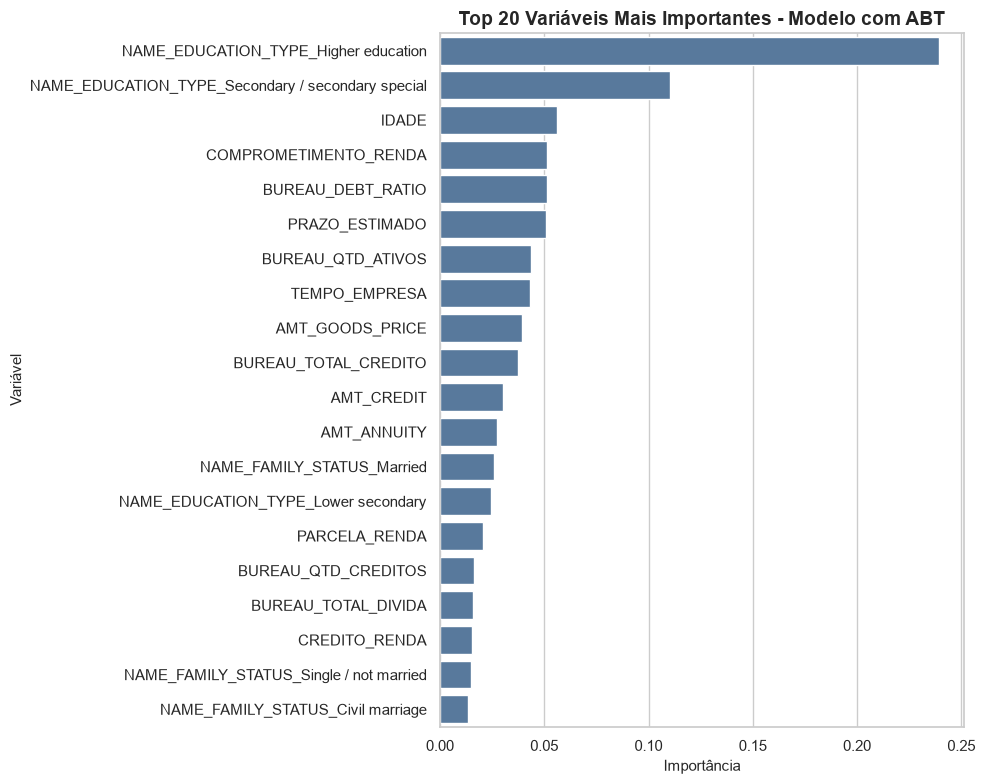

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\evaluation_feature_importance_abt.png


,feature,importance
18,NAME_EDUCATION_TYPE_Higher education,0.239366
21,NAME_EDUCATION_TYPE_Secondary / secondary special,0.110181
4,IDADE,0.056324
10,COMPROMETIMENTO_RENDA,0.051404
16,BUREAU_DEBT_RATIO,0.051250
11,PRAZO_ESTIMADO,0.050819
13,BUREAU_QTD_ATIVOS,0.043646
5,TEMPO_EMPRESA,0.043200
3,AMT_GOODS_PRICE,0.039321
14,BUREAU_TOTAL_CREDITO,0.037227


In [69]:
# ============================================================
# Feature Importance corrigido para modelo treinado com ABT
# ============================================================

def get_feature_names_from_pipeline(pipe):
    preprocessor = pipe.named_steps["preprocessor"]

    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:

        if name == "num":
            feature_names.extend(list(cols))

        elif name == "cat":
            ohe = transformer.named_steps["onehot"]
            encoded_names = ohe.get_feature_names_out(cols)
            feature_names.extend(encoded_names)

    return feature_names


classifier = model.named_steps["classifier"]
feature_names = get_feature_names_from_pipeline(model)

importances = classifier.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 20
plot_df = fi_df.head(top_n)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=plot_df,
    x="importance",
    y="feature",
    color="#4C78A8"
)

plt.title("Top 20 Variáveis Mais Importantes - Modelo com ABT", fontsize=14, fontweight="bold")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()

output_path = FIGURES_DIR / "evaluation_feature_importance_abt.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)

display(fi_df.head(30))

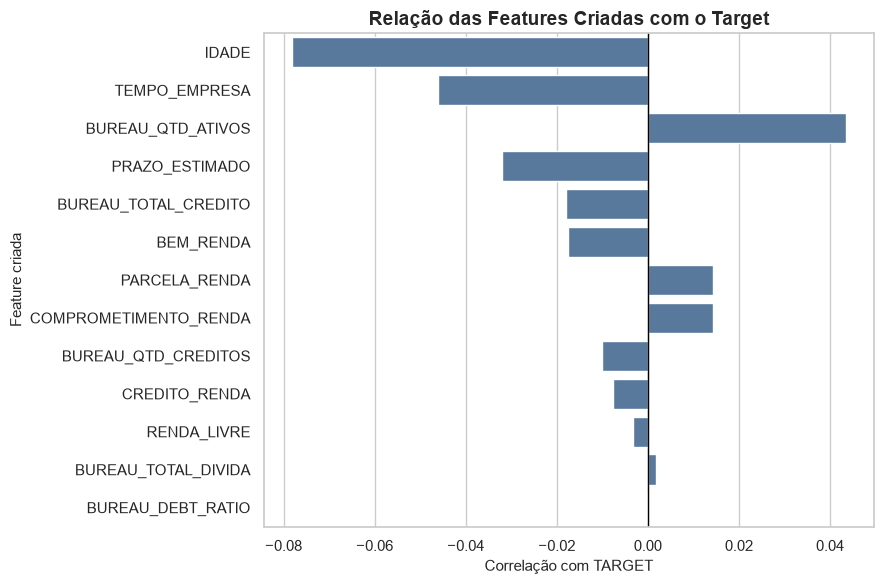

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\abt_features_corr_target.png


,correlacao_TARGET
IDADE,-0.078239
TEMPO_EMPRESA,-0.046052
BUREAU_QTD_ATIVOS,0.043569
PRAZO_ESTIMADO,-0.032062
BUREAU_TOTAL_CREDITO,-0.018020
BEM_RENDA,-0.017530
PARCELA_RENDA,0.014328
COMPROMETIMENTO_RENDA,0.014328
BUREAU_QTD_CREDITOS,-0.010020
CREDITO_RENDA,-0.007727


In [70]:
# ============================================================
# Gráfico para slide da ABT:
# ============================================================

features_abt = [
    "IDADE",
    "TEMPO_EMPRESA",
    "CREDITO_RENDA",
    "PARCELA_RENDA",
    "BEM_RENDA",
    "RENDA_LIVRE",
    "COMPROMETIMENTO_RENDA",
    "PRAZO_ESTIMADO",
    "BUREAU_QTD_CREDITOS",
    "BUREAU_QTD_ATIVOS",
    "BUREAU_TOTAL_CREDITO",
    "BUREAU_TOTAL_DIVIDA",
    "BUREAU_DEBT_RATIO",
    "TARGET"
]

features_existentes = [col for col in features_abt if col in df.columns]

corr_df = df[features_existentes].corr(numeric_only=True)

target_corr = (
    corr_df["TARGET"]
    .drop("TARGET")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    color="#4C78A8"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Relação das Features Criadas com o Target", fontsize=14, fontweight="bold")
plt.xlabel("Correlação com TARGET")
plt.ylabel("Feature criada")
plt.tight_layout()

output_path = FIGURES_DIR / "abt_features_corr_target.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)

display(target_corr.to_frame("correlacao_TARGET"))

In [71]:
print("Figuras geradas:")

for p in sorted(FIGURES_DIR.glob("*.png")):
    print("-", p.name)

Figuras geradas:
- abt_features_corr_target.png
- eda_age_distribution.png
- eda_correlation_heatmap.png
- eda_credit_by_target.png
- eda_income_distribution.png
- eda_target_distribution.png
- evaluation_confusion_matrix.png
- evaluation_feature_importance.png
- evaluation_feature_importance_abt.png
- evaluation_precision_recall_curve.png
- evaluation_roc_curve.png
- insight_1_target_barras.png
- insight_1_target_pizza.png
- insight_2_renda_boxplot.png
- insight_2_renda_histograma.png
- insight_3_debt_ratio_proxy_boxplot.png
- monitoring_distribution_drift_example.png
- monitoring_psi_top_features.png
- shap_bar_plot.png
- shap_summary_plot.png


## 1. Análise Exploratória dos Dados

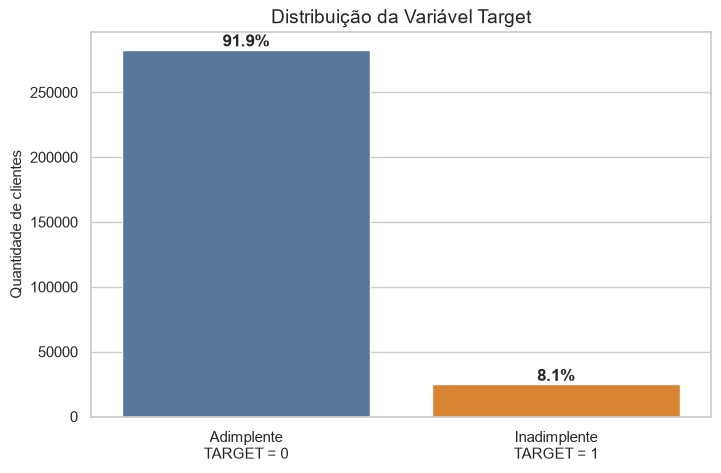

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\eda_target_distribution.png


In [72]:
# ============================================================
# Gráfico 1 - Distribuição do TARGET
# ============================================================
target_counts = df["TARGET"].value_counts().sort_index()
target_percent = df["TARGET"].value_counts(normalize=True).sort_index() * 100

plot_df = pd.DataFrame({
    "TARGET": target_counts.index.astype(str),
    "Quantidade": target_counts.values,
    "Percentual": target_percent.values
})
plot_df["Classe"] = plot_df["TARGET"].map({"0": "Adimplente\nTARGET = 0", "1": "Inadimplente\nTARGET = 1"}).fillna(plot_df["TARGET"])

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_df, x="Classe", y="Quantidade", palette=["#4C78A8", "#F58518"])
plt.title("Distribuição da Variável Target")
plt.xlabel("")
plt.ylabel("Quantidade de clientes")

for i, row in plot_df.iterrows():
    ax.text(i, row["Quantidade"], f'{row["Percentual"]:.1f}%', ha="center", va="bottom", fontweight="bold")

output_path = FIGURES_DIR / "eda_target_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico salvo em:", output_path)

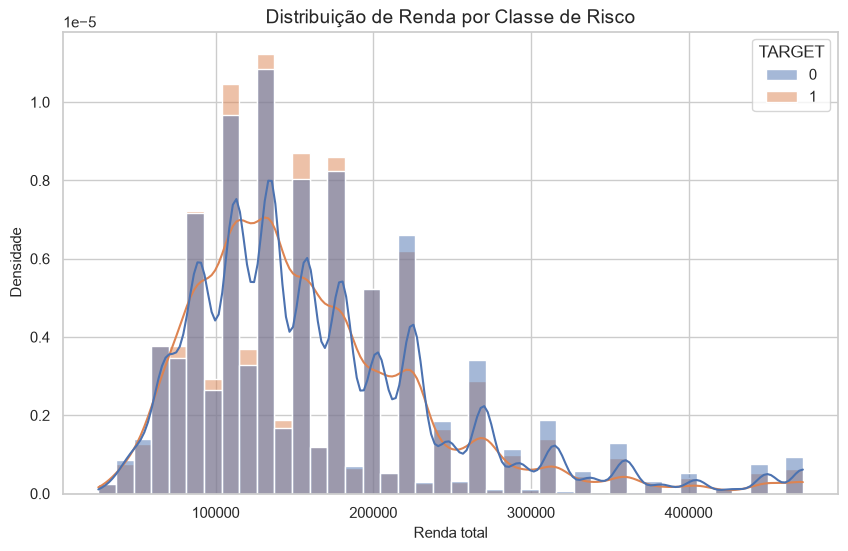

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\eda_income_distribution.png


In [73]:
# ============================================================
# Gráfico 3 - Distribuição de renda
# ============================================================
if "AMT_INCOME_TOTAL" in df.columns:
    income = df["AMT_INCOME_TOTAL"].clip(upper=df["AMT_INCOME_TOTAL"].quantile(0.99))
    plot_df = pd.DataFrame({"Renda": income, "TARGET": df["TARGET"]})

    plt.figure(figsize=(10, 6))
    sns.histplot(data=plot_df, x="Renda", hue="TARGET", bins=40, kde=True, stat="density", common_norm=False)
    plt.title("Distribuição de Renda por Classe de Risco")
    plt.xlabel("Renda total")
    plt.ylabel("Densidade")
    output_path = FIGURES_DIR / "eda_income_distribution.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gráfico salvo em:", output_path)
else:
    print("Coluna AMT_INCOME_TOTAL não encontrada. Pulando gráfico de renda.")

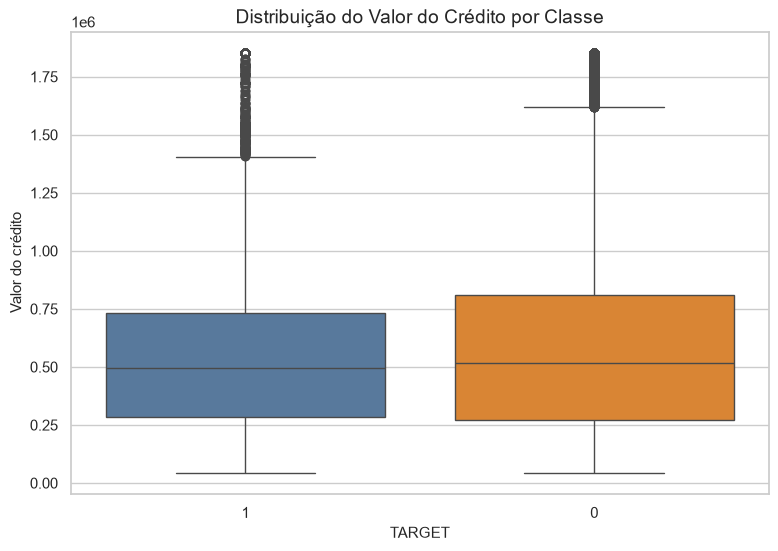

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\eda_credit_by_target.png


In [74]:
# ============================================================
# Gráfico 4 - Valor do crédito por TARGET
# ============================================================
if "AMT_CREDIT" in df.columns:
    credit = df["AMT_CREDIT"].clip(upper=df["AMT_CREDIT"].quantile(0.99))
    plot_df = pd.DataFrame({"Valor do crédito": credit, "TARGET": df["TARGET"].astype(str)})

    plt.figure(figsize=(9, 6))
    sns.boxplot(data=plot_df, x="TARGET", y="Valor do crédito", palette=["#4C78A8", "#F58518"])
    plt.title("Distribuição do Valor do Crédito por Classe")
    plt.xlabel("TARGET")
    plt.ylabel("Valor do crédito")
    output_path = FIGURES_DIR / "eda_credit_by_target.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gráfico salvo em:", output_path)
else:
    print("Coluna AMT_CREDIT não encontrada. Pulando gráfico de crédito.")

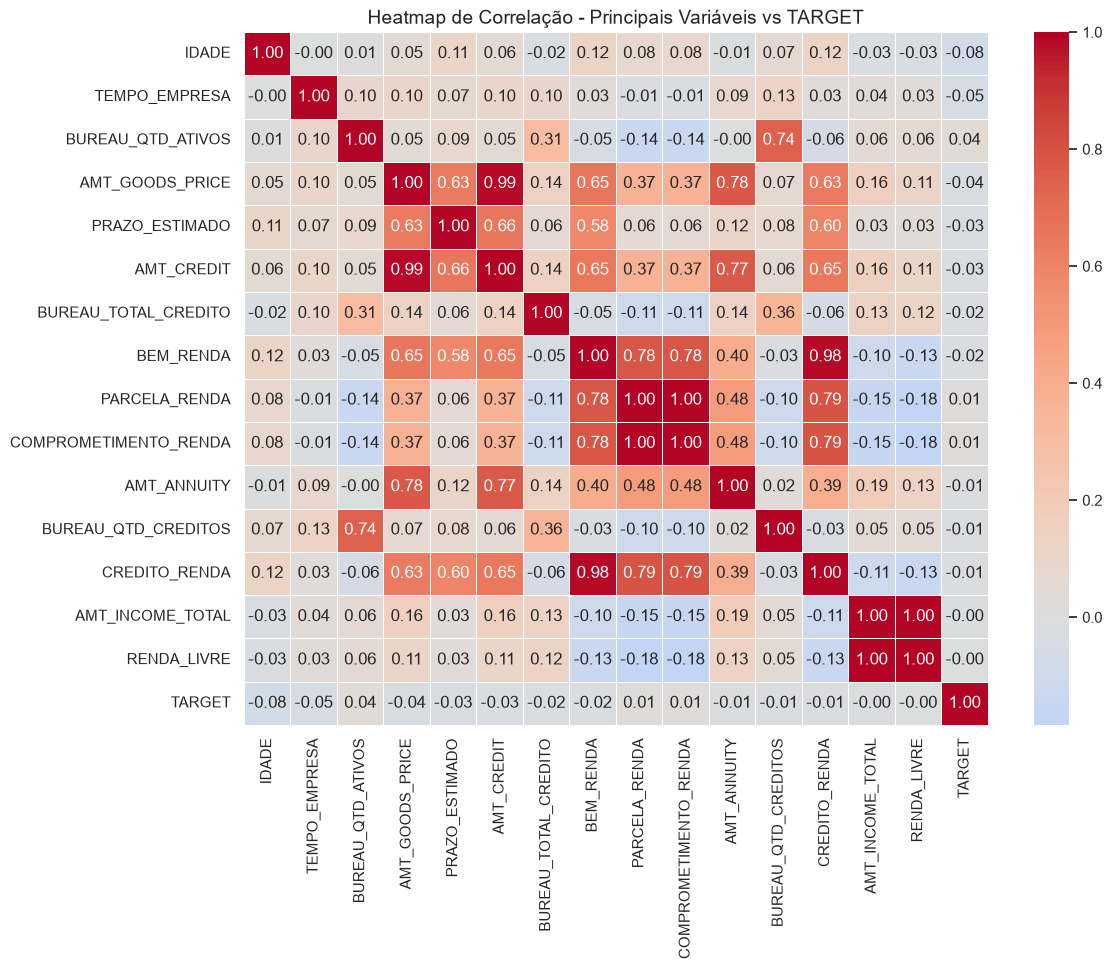

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\eda_correlation_heatmap.png


In [75]:
# ============================================================
# Gráfico 5 - Heatmap de correlação com TARGET
# ============================================================
numeric_df = df.select_dtypes(include=[np.number]).copy()
if "TARGET" in numeric_df.columns:
    corr_target = numeric_df.corr(numeric_only=True)["TARGET"].drop("TARGET", errors="ignore").abs().sort_values(ascending=False)
    top_cols = corr_target.head(15).index.tolist() + ["TARGET"]
    corr_matrix = numeric_df[top_cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 9))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
    plt.title("Heatmap de Correlação - Principais Variáveis vs TARGET")
    output_path = FIGURES_DIR / "eda_correlation_heatmap.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gráfico salvo em:", output_path)
else:
    print("Não há colunas numéricas suficientes para correlação.")

## 2. Modelo e Feature Importance

In [76]:
# ============================================================
# Preparação simples para modelagem
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Remove linhas sem TARGET, se houver
model_df = df.dropna(subset=["TARGET"]).copy()

# Evita colunas de identificação muito óbvias, mas mantém o restante
id_like_cols = [c for c in model_df.columns if c.upper() in ["SK_ID_CURR", "ID", "CLIENT_ID", "CUSTOMER_ID"]]

X = model_df.drop(columns=["TARGET"] + id_like_cols, errors="ignore")
y = model_df["TARGET"].astype(int)

# Para evitar notebook muito pesado, limita colunas categóricas com cardinalidade muito alta
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
high_card_cols = [c for c in cat_cols if X[c].nunique(dropna=True) > 50]
if high_card_cols:
    print("Removendo categóricas de alta cardinalidade:", high_card_cols[:20])
    X = X.drop(columns=high_card_cols)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Features numéricas:", len(numeric_features))
print("Features categóricas:", len(categorical_features))
print("Target rate:", round(y.mean() * 100, 2), "%")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features),
    ],
    remainder="drop"
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)

Features numéricas: 17
Features categóricas: 2
Target rate: 8.07 %
Treino: (246008, 19) Teste: (61503, 19)


In [77]:
# ============================================================
# Carregar modelo existente ou treinar um novo XGBoost
# ============================================================
import joblib

model_candidates = []
for folder in [MODELS_DIR, PROJECT_ROOT, PROJECT_ROOT / "mlops", PROJECT_ROOT / "artifacts"]:
    if folder.exists():
        model_candidates.extend(list(folder.rglob("*.pkl")))
        model_candidates.extend(list(folder.rglob("*.joblib")))

print("Modelos encontrados:")
for p in model_candidates:
    print("-", p)

model = None
model_path = None

# prioriza xgboost_model.pkl, model.pkl ou qualquer arquivo com xgb/xgboost no nome
priority = sorted(
    model_candidates,
    key=lambda p: (
        not any(w in p.name.lower() for w in ["xgboost", "xgb", "model"]),
        str(p).lower()
    )
)

for p in priority:
    try:
        model = joblib.load(p)
        model_path = p
        print("\nModelo carregado de:", model_path)
        break
    except Exception as e:
        print("Não consegui carregar", p, "->", e)

if model is None:
    print("\nNenhum modelo .pkl/.joblib válido encontrado. Vou treinar um modelo novo para a avaliação.")
    try:
        from xgboost import XGBClassifier
        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
        model_name = "XGBoost"
    except Exception as e:
        print("XGBoost não disponível. Usando RandomForest como fallback.")
        from sklearn.ensemble import RandomForestClassifier
        clf = RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        )
        model_name = "RandomForest fallback"

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    model.fit(X_train, y_train)
    model_path = MODELS_DIR / "xgboost_model.pkl"
    joblib.dump(model, model_path)
    print(f"Modelo treinado ({model_name}) e salvo em: {model_path}")
else:
    print("Tipo do modelo:", type(model))

Modelos encontrados:
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\models\xgboost_model.pkl
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\assets\modelo.pkl
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\assets\preprocessor.pkl
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\models\xgboost_model.pkl
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\.venv\Lib\site-packages\numpy\_core\tests\data\astype_copy.pkl
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\.venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py27_np17.pkl
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\.venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py33_np18.pkl
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\.venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py34_np19.pkl
- c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\.venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py35_np19.pkl
- c:\Users\Megum

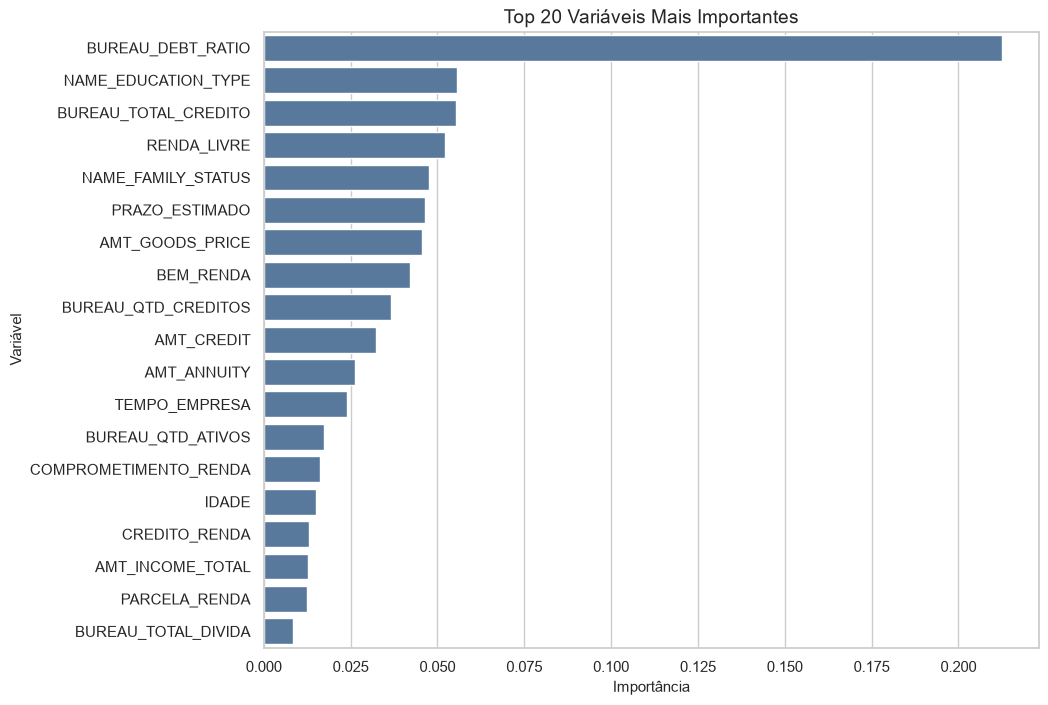

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\evaluation_feature_importance.png


,feature,importance
18,BUREAU_DEBT_RATIO,0.212502
4,NAME_EDUCATION_TYPE,0.055598
16,BUREAU_TOTAL_CREDITO,0.055337
11,RENDA_LIVRE,0.052142
5,NAME_FAMILY_STATUS,0.047439
13,PRAZO_ESTIMADO,0.046386
3,AMT_GOODS_PRICE,0.045510
10,BEM_RENDA,0.042164
14,BUREAU_QTD_CREDITOS,0.036585
1,AMT_CREDIT,0.032303


In [78]:
# ============================================================
# Gráfico: Importância das Variáveis
# ============================================================
def get_feature_names_from_pipeline(pipe, X_columns):
    """Obtém nomes das features depois do pré-processamento, quando possível."""
    if not hasattr(pipe, "named_steps") or "preprocessor" not in pipe.named_steps:
        return list(X_columns)
    prep = pipe.named_steps["preprocessor"]
    names = []
    try:
        for name, transformer, cols in prep.transformers_:
            if name == "num":
                names.extend(list(cols))
            elif name == "cat":
                ohe = transformer.named_steps.get("onehot")
                names.extend(ohe.get_feature_names_out(cols).tolist())
        return names
    except Exception:
        return list(X_columns)

classifier = model.named_steps["classifier"] if hasattr(model, "named_steps") and "classifier" in model.named_steps else model
feature_names = get_feature_names_from_pipeline(model, X.columns)

importances = None
if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
elif hasattr(classifier, "coef_"):
    importances = np.abs(classifier.coef_).ravel()

if importances is not None:
    n = min(len(importances), len(feature_names))
    fi_df = pd.DataFrame({
        "feature": feature_names[:n],
        "importance": importances[:n]
    }).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi_df, x="importance", y="feature", color="#4C78A8")
    plt.title("Top 20 Variáveis Mais Importantes")
    plt.xlabel("Importância")
    plt.ylabel("Variável")
    output_path = FIGURES_DIR / "evaluation_feature_importance.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gráfico salvo em:", output_path)
    display(fi_df)
else:
    print("Este modelo não possui feature_importances_ nem coef_. Pulando gráfico.")

In [79]:
print("Tipo atual do model:", type(model))

if hasattr(model, "named_steps"):
    print("Modelo é Pipeline.")
    print("Etapas:", model.named_steps.keys())
else:
    print("Modelo NÃO é Pipeline.")

Tipo atual do model: <class 'xgboost.sklearn.XGBClassifier'>
Modelo NÃO é Pipeline.


## 3. Explicabilidade com SHAP

In [80]:
# ============================================================
# Teste do pré-processamento antes do SHAP
# ============================================================

X_sample_teste = X_test.sample(min(10, len(X_test)), random_state=42)

X_transformed_teste = model_pipeline.named_steps["preprocessor"].transform(X_sample_teste)

print("Shape original:", X_sample_teste.shape)
print("Shape transformado:", X_transformed_teste.shape)

teste_df = pd.DataFrame(X_transformed_teste)

print("\nTipos depois do preprocessor:")
print(teste_df.dtypes.value_counts())

display(teste_df.head())

Shape original: (10, 19)
Shape transformado: (10, 28)

Tipos depois do preprocessor:
float64    28
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,270000.0,1031053.5,34204.5,783000.0,46.97,1.30,3.82,0.13,2.90,235795.5,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,157500.0,450000.0,42075.0,450000.0,32.55,0.85,2.86,0.27,2.86,115425.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,112500.0,195543.0,13198.5,148500.0,41.20,1.95,1.74,0.12,1.32,99301.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,99000.0,229500.0,14796.0,229500.0,59.18,0.00,2.32,0.15,2.32,84204.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,405000.0,450000.0,30442.5,450000.0,29.17,2.21,1.11,0.08,1.11,374557.5,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Tipo atual do model_pipeline: <class 'sklearn.pipeline.Pipeline'>
Gerando SHAP com dados já pré-processados...
Shape usado no SHAP: (500, 28)
Tipos de dados no SHAP:
float64    28
Name: count, dtype: int64


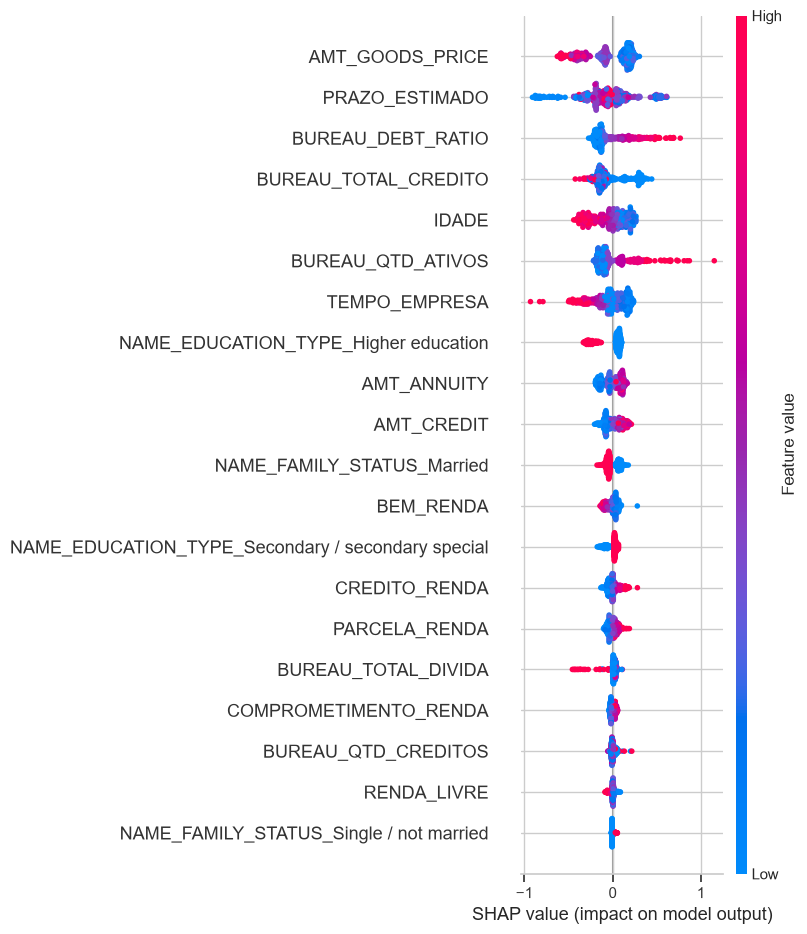

SHAP summary salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\shap_summary_plot.png


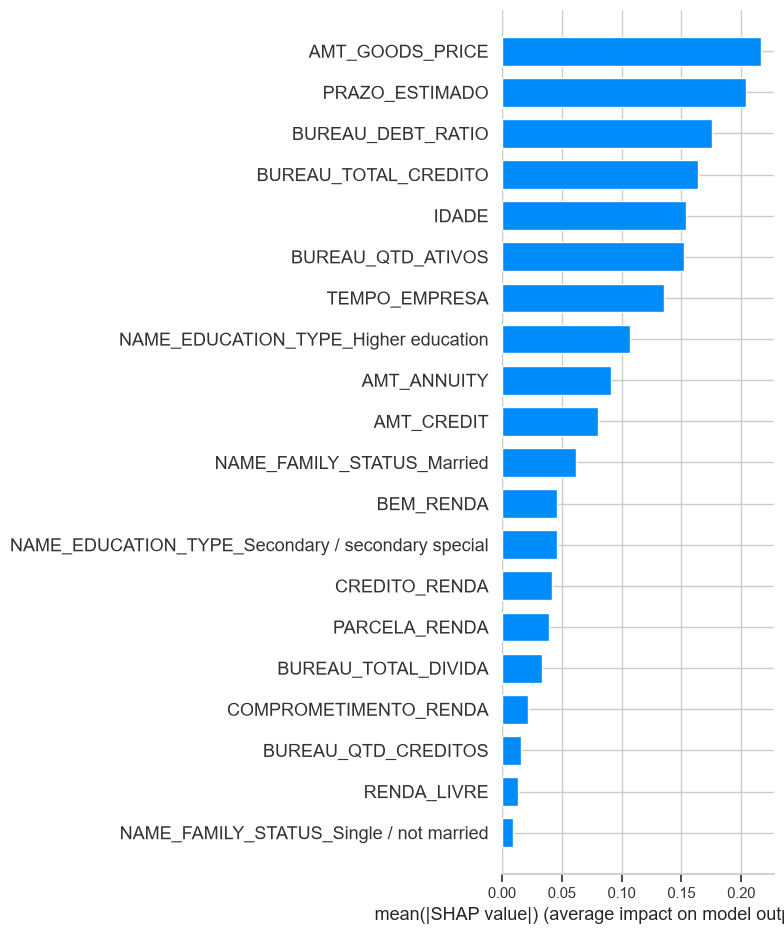

SHAP bar salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\shap_bar_plot.png


In [81]:
# ============================================================
# SHAP - explicabilidade global e individual
# Versão segura usando model_pipeline
# ============================================================

try:
    import shap
    shap_available = True
except Exception as e:
    shap_available = False
    print("Biblioteca SHAP não encontrada.")
    print("Para instalar, use: pip install shap")
    print("Erro:", e)


def get_feature_names_from_pipeline(pipe):
    preprocessor_local = pipe.named_steps["preprocessor"]

    feature_names = []

    for name, transformer, cols in preprocessor_local.transformers_:

        if name == "num":
            feature_names.extend(list(cols))

        elif name == "cat":
            ohe = transformer.named_steps["onehot"]
            encoded_names = ohe.get_feature_names_out(cols)
            feature_names.extend(encoded_names)

    return feature_names


if shap_available:

    print("Tipo atual do model_pipeline:", type(model_pipeline))

    if not hasattr(model_pipeline, "named_steps"):
        raise TypeError(
            "model_pipeline não é Pipeline. Rode novamente a célula de treino com Pipeline antes do SHAP."
        )

    print("Gerando SHAP com dados já pré-processados...")

    sample_size = min(500, len(X_test))
    X_sample = X_test.sample(sample_size, random_state=42)

    preprocessor_model = model_pipeline.named_steps["preprocessor"]
    classifier = model_pipeline.named_steps["classifier"]

    X_sample_transformed = preprocessor_model.transform(X_sample)

    feature_names = get_feature_names_from_pipeline(model_pipeline)

    X_sample_shap = pd.DataFrame(
        X_sample_transformed,
        columns=feature_names,
        index=X_sample.index
    )

    # Garante tudo numérico
    X_sample_shap = X_sample_shap.apply(pd.to_numeric, errors="coerce").fillna(0)

    print("Shape usado no SHAP:", X_sample_shap.shape)
    print("Tipos de dados no SHAP:")
    print(X_sample_shap.dtypes.value_counts())

    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_sample_shap)

    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values

    # SHAP Summary Plot
    plt.figure()
    shap.summary_plot(
        shap_values_plot,
        X_sample_shap,
        show=False,
        max_display=20
    )

    output_path = FIGURES_DIR / "shap_summary_plot.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("SHAP summary salvo em:", output_path)

    # SHAP Bar Plot
    plt.figure()
    shap.summary_plot(
        shap_values_plot,
        X_sample_shap,
        plot_type="bar",
        show=False,
        max_display=20
    )

    output_path = FIGURES_DIR / "shap_bar_plot.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("SHAP bar salvo em:", output_path)

## 4. Monitoramento - PSI e Drift

In [82]:
# ============================================================
# Função PSI - Population Stability Index
# ============================================================
def calculate_psi(expected, actual, buckets=10):
    """
    Calcula PSI entre uma distribuição esperada e uma distribuição atual.
    expected = referência, normalmente treino
    actual = atual/produção, ou teste neste notebook
    """
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return np.nan

    breakpoints = np.quantile(expected, np.linspace(0, 1, buckets + 1))
    breakpoints = np.unique(breakpoints)

    if len(breakpoints) <= 2:
        breakpoints = np.linspace(expected.min(), expected.max(), buckets + 1)

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_perc = expected_counts / max(expected_counts.sum(), 1)
    actual_perc = actual_counts / max(actual_counts.sum(), 1)

    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)

    psi_values = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)
    return float(np.sum(psi_values))

def interpret_psi(psi):
    if pd.isna(psi):
        return "Não calculável"
    if psi < 0.10:
        return "Estável"
    if psi < 0.25:
        return "Atenção / mudança moderada"
    return "Drift significativo"

print("Interpretação padrão:")
print("PSI < 0.10  -> Estável")
print("0.10-0.25   -> Atenção")
print("PSI > 0.25  -> Drift significativo")

Interpretação padrão:
PSI < 0.10  -> Estável
0.10-0.25   -> Atenção
PSI > 0.25  -> Drift significativo


,feature,psi,interpretacao
2,AMT_ANNUITY,0.000278,Estável
15,BUREAU_TOTAL_DIVIDA,0.000259,Estável
9,RENDA_LIVRE,0.000227,Estável
11,PRAZO_ESTIMADO,0.000223,Estável
0,AMT_INCOME_TOTAL,0.000220,Estável
5,TEMPO_EMPRESA,0.000217,Estável
4,IDADE,0.000196,Estável
16,BUREAU_DEBT_RATIO,0.000151,Estável
14,BUREAU_TOTAL_CREDITO,0.000148,Estável
6,CREDITO_RENDA,0.000141,Estável


Relatório PSI salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\psi_report.csv


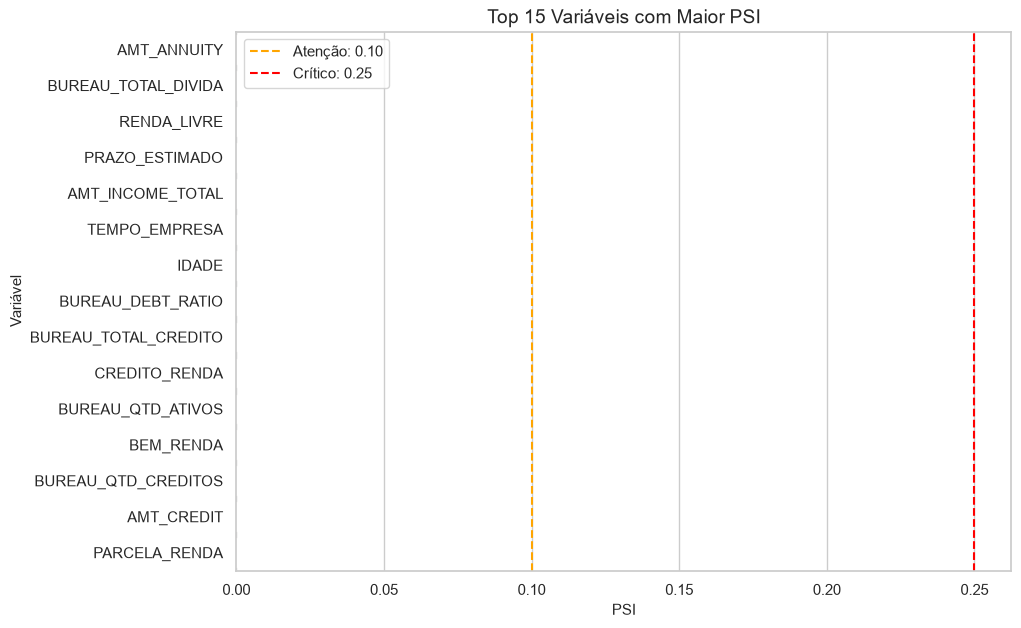

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\monitoring_psi_top_features.png


In [83]:
# ============================================================
# PSI por variável: treino vs teste
# ============================================================
psi_rows = []
for col in numeric_features[:50]:
    psi = calculate_psi(X_train[col], X_test[col], buckets=10)
    psi_rows.append({
        "feature": col,
        "psi": psi,
        "interpretacao": interpret_psi(psi)
    })

psi_df = pd.DataFrame(psi_rows).sort_values("psi", ascending=False)
display(psi_df.head(20))

psi_path = REPORTS_DIR / "psi_report.csv"
psi_df.to_csv(psi_path, index=False, encoding="utf-8-sig")
print("Relatório PSI salvo em:", psi_path)

plt.figure(figsize=(10, 7))
plot_df = psi_df.head(15).copy()
sns.barplot(data=plot_df, x="psi", y="feature", color="#F58518")
plt.axvline(0.10, color="orange", linestyle="--", label="Atenção: 0.10")
plt.axvline(0.25, color="red", linestyle="--", label="Crítico: 0.25")
plt.title("Top 15 Variáveis com Maior PSI")
plt.xlabel("PSI")
plt.ylabel("Variável")
plt.legend()
output_path = FIGURES_DIR / "monitoring_psi_top_features.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico salvo em:", output_path)

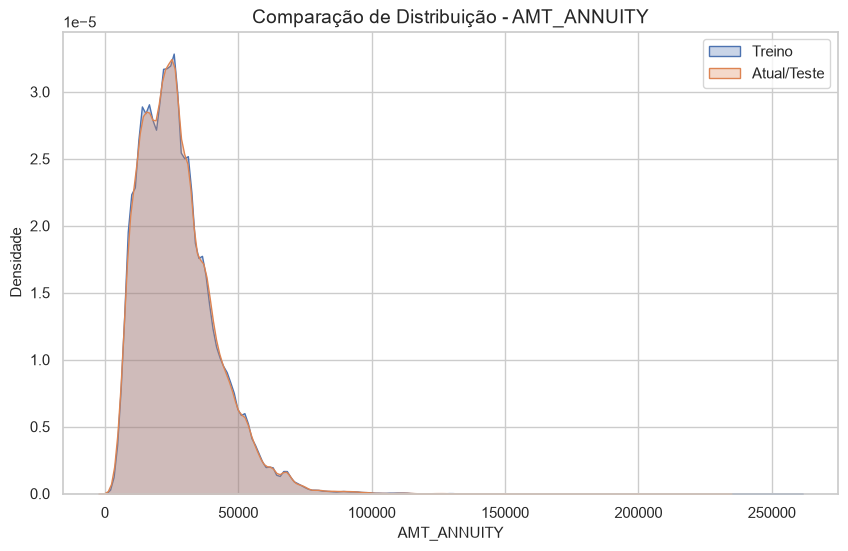

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\monitoring_distribution_drift_example.png


In [84]:
# ============================================================
# Gráfico: exemplo de drift em uma variável importante
# ============================================================
if len(psi_df) > 0:
    feature_to_plot = psi_df.iloc[0]["feature"]
    plt.figure(figsize=(10, 6))
    sns.kdeplot(X_train[feature_to_plot].dropna(), label="Treino", fill=True, alpha=0.3)
    sns.kdeplot(X_test[feature_to_plot].dropna(), label="Atual/Teste", fill=True, alpha=0.3)
    plt.title(f"Comparação de Distribuição - {feature_to_plot}")
    plt.xlabel(feature_to_plot)
    plt.ylabel("Densidade")
    plt.legend()
    output_path = FIGURES_DIR / "monitoring_distribution_drift_example.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gráfico salvo em:", output_path)
else:
    print("Sem variáveis para gráfico de drift.")

## Como explicar para a banca

- **EDA**: mostra o perfil dos clientes e evidencia o desbalanceamento da base.
- **SHAP global**: explica quais variáveis mais influenciam o modelo como um todo.
- **SHAP individual**: explica por que um cliente específico recebeu determinado score.
- **PSI**: monitora se a população atual mudou em relação à base de referência. Um PSI de 0,18 indica mudança moderada e necessidade de acompanhamento, mas não retreinamento automático imediato.

In [85]:
# ============================================================
# Conferência final dos arquivos gerados
# ============================================================
print("Figuras geradas:")
for p in sorted(FIGURES_DIR.glob("*.png")):
    print("-", p.name)

Figuras geradas:
- abt_features_corr_target.png
- eda_age_distribution.png
- eda_correlation_heatmap.png
- eda_credit_by_target.png
- eda_income_distribution.png
- eda_target_distribution.png
- evaluation_confusion_matrix.png
- evaluation_feature_importance.png
- evaluation_feature_importance_abt.png
- evaluation_precision_recall_curve.png
- evaluation_roc_curve.png
- insight_1_target_barras.png
- insight_1_target_pizza.png
- insight_2_renda_boxplot.png
- insight_2_renda_histograma.png
- insight_3_debt_ratio_proxy_boxplot.png
- monitoring_distribution_drift_example.png
- monitoring_psi_top_features.png
- shap_bar_plot.png
- shap_summary_plot.png


GRAFICOS INSIGHTS

In [87]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Garante que a pasta existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Pasta de figuras:", FIGURES_DIR)
print("Shape da base:", df.shape)
print("Colunas disponíveis:", df.columns.tolist()[:20])

Pasta de figuras: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures
Shape da base: (307511, 21)
Colunas disponíveis: ['SK_ID_CURR', 'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'IDADE', 'TEMPO_EMPRESA', 'CREDITO_RENDA', 'PARCELA_RENDA', 'BEM_RENDA', 'RENDA_LIVRE', 'COMPROMETIMENTO_RENDA', 'PRAZO_ESTIMADO', 'BUREAU_QTD_CREDITOS', 'BUREAU_QTD_ATIVOS', 'BUREAU_TOTAL_CREDITO', 'BUREAU_TOTAL_DIVIDA']


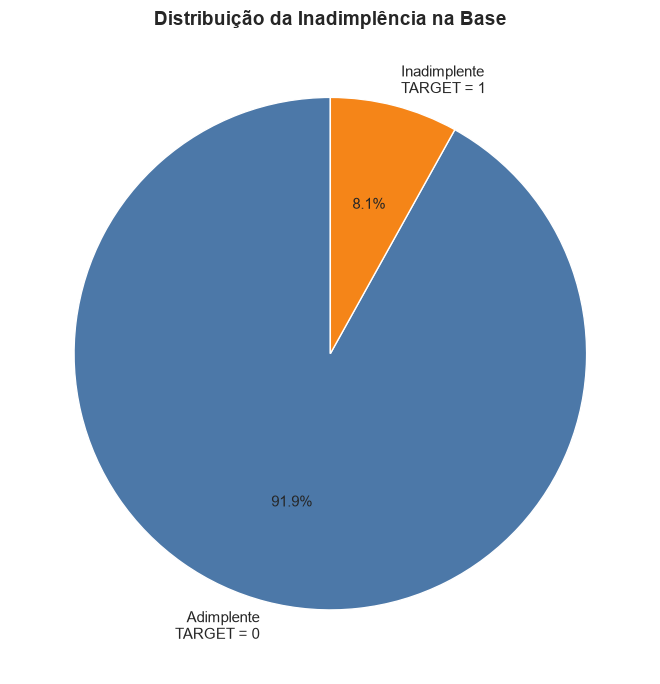

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\insight_1_target_pizza.png
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [88]:
# ============================================================
# Insight 1 - Percentual de inadimplentes
# Gráfico de pizza do TARGET
# ============================================================

target_counts = df["TARGET"].value_counts().sort_index()
target_percent = df["TARGET"].value_counts(normalize=True).sort_index() * 100

labels = ["Adimplente\nTARGET = 0", "Inadimplente\nTARGET = 1"]
colors = ["#4C78A8", "#F58518"]

plt.figure(figsize=(7, 7))

plt.pie(
    target_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 11}
)

plt.title("Distribuição da Inadimplência na Base", fontsize=14, fontweight="bold")
plt.tight_layout()

output_path = FIGURES_DIR / "insight_1_target_pizza.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)
print(target_percent)

A base apresenta forte desbalanceamento: aproximadamente 92% dos clientes são adimplentes e 8% inadimplentes.

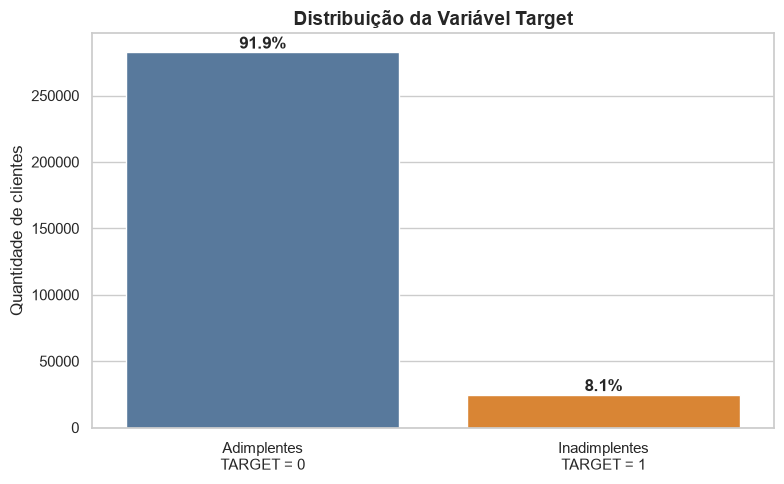

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\insight_1_target_barras.png


In [89]:
# ============================================================
# Insight 1 - Percentual de inadimplentes
# Gráfico de barras
# ============================================================

target_counts = df["TARGET"].value_counts().sort_index()
target_percent = df["TARGET"].value_counts(normalize=True).sort_index() * 100

plot_df = pd.DataFrame({
    "TARGET": target_counts.index,
    "Quantidade": target_counts.values,
    "Percentual": target_percent.values
})

plot_df["Classe"] = plot_df["TARGET"].map({
    0: "Adimplentes\nTARGET = 0",
    1: "Inadimplentes\nTARGET = 1"
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_df,
    x="Classe",
    y="Quantidade",
    palette=["#4C78A8", "#F58518"]
)

for i, row in plot_df.iterrows():
    ax.text(
        i,
        row["Quantidade"],
        f'{row["Percentual"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Distribuição da Variável Target", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Quantidade de clientes")
plt.tight_layout()

output_path = FIGURES_DIR / "insight_1_target_barras.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)

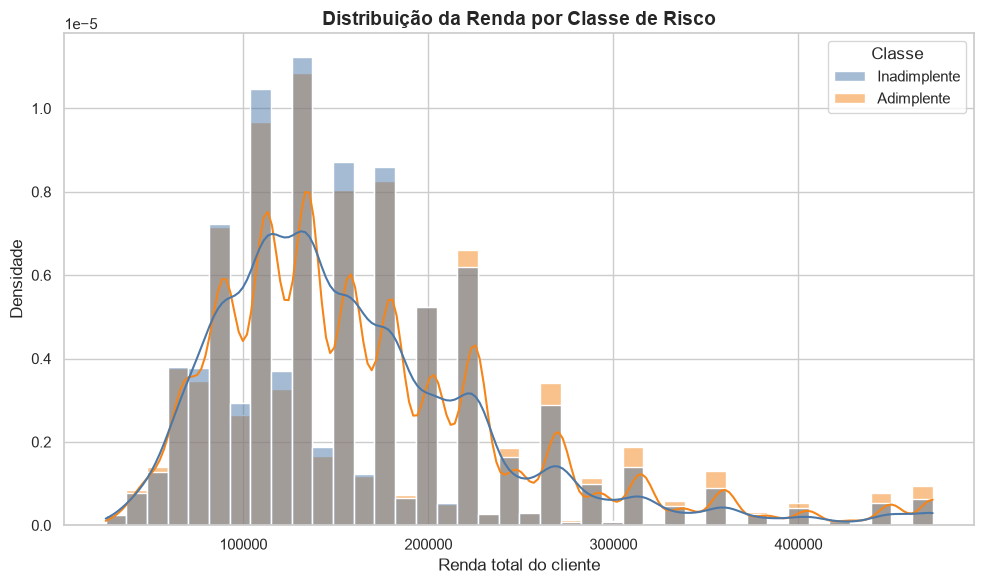

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\insight_2_renda_histograma.png


In [90]:
# ============================================================
# Insight 2 - Distribuição da renda por TARGET
# Histograma
# ============================================================

income_col = "AMT_INCOME_TOTAL"

if income_col in df.columns:

    plot_df = df[[income_col, "TARGET"]].copy()
    plot_df = plot_df.dropna(subset=[income_col, "TARGET"])

    # Remove outliers extremos só para visualização
    limite_superior = plot_df[income_col].quantile(0.99)
    plot_df[income_col] = plot_df[income_col].clip(upper=limite_superior)

    plot_df["Classe"] = plot_df["TARGET"].map({
        0: "Adimplente",
        1: "Inadimplente"
    })

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=plot_df,
        x=income_col,
        hue="Classe",
        bins=40,
        kde=True,
        stat="density",
        common_norm=False,
        palette=["#4C78A8", "#F58518"]
    )

    plt.title("Distribuição da Renda por Classe de Risco", fontsize=14, fontweight="bold")
    plt.xlabel("Renda total do cliente")
    plt.ylabel("Densidade")
    plt.tight_layout()

    output_path = FIGURES_DIR / "insight_2_renda_histograma.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Gráfico salvo em:", output_path)

else:
    print(f"Coluna {income_col} não encontrada na base.")

Clientes inadimplentes apresentam maior concentração em faixas de renda mais baixas, indicando possível relação entre capacidade financeira e risco de crédito.

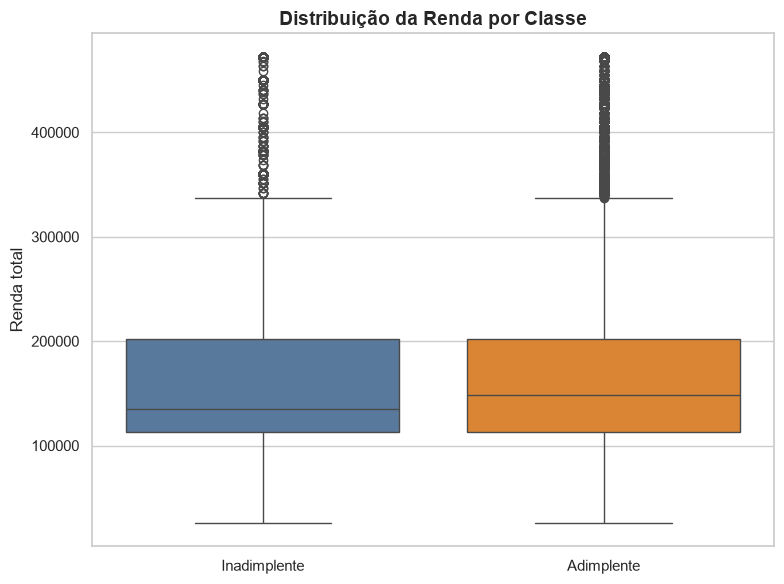

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\insight_2_renda_boxplot.png


In [91]:
# ============================================================
# Insight 2 - Renda por TARGET
# Boxplot
# ============================================================

income_col = "AMT_INCOME_TOTAL"

if income_col in df.columns:

    plot_df = df[[income_col, "TARGET"]].copy()
    plot_df = plot_df.dropna(subset=[income_col, "TARGET"])

    limite_superior = plot_df[income_col].quantile(0.99)
    plot_df[income_col] = plot_df[income_col].clip(upper=limite_superior)

    plot_df["Classe"] = plot_df["TARGET"].map({
        0: "Adimplente",
        1: "Inadimplente"
    })

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=plot_df,
        x="Classe",
        y=income_col,
        palette=["#4C78A8", "#F58518"]
    )

    plt.title("Distribuição da Renda por Classe", fontsize=14, fontweight="bold")
    plt.xlabel("")
    plt.ylabel("Renda total")
    plt.tight_layout()

    output_path = FIGURES_DIR / "insight_2_renda_boxplot.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Gráfico salvo em:", output_path)

else:
    print(f"Coluna {income_col} não encontrada na base.")

In [92]:
# ============================================================
# Procurar colunas candidatas para Debt Ratio / Bureau
# ============================================================

keywords = [
    "DEBT",
    "RATIO",
    "BUREAU",
    "CREDIT",
    "INCOME",
    "ANNUITY",
    "AMT"
]

candidate_cols = []

for col in df.columns:
    col_upper = col.upper()
    if any(key in col_upper for key in keywords):
        candidate_cols.append(col)

print("Colunas candidatas encontradas:")
for col in candidate_cols:
    print("-", col)

Colunas candidatas encontradas:
- AMT_INCOME_TOTAL
- AMT_CREDIT
- AMT_ANNUITY
- AMT_GOODS_PRICE
- CREDITO_RENDA
- BUREAU_QTD_CREDITOS
- BUREAU_QTD_ATIVOS
- BUREAU_TOTAL_CREDITO
- BUREAU_TOTAL_DIVIDA
- BUREAU_DEBT_RATIO


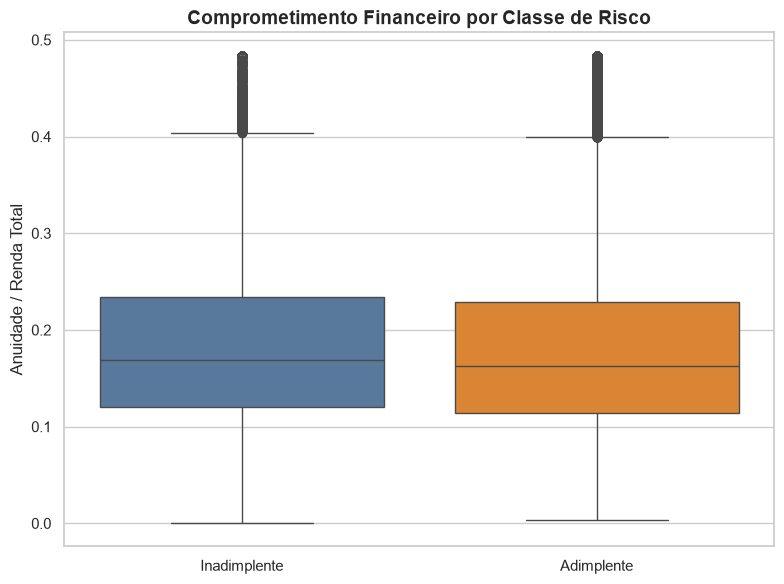

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\insight_3_debt_ratio_proxy_boxplot.png


,média,mediana,qtde
Classe,,,
Adimplente,0.179500,0.162280,282674
Inadimplente,0.184405,0.169294,24825


In [93]:
# ============================================================
# Insight 3 - Proxy de comprometimento financeiro
# AMT_ANNUITY / AMT_INCOME_TOTAL
# ============================================================

required_cols = ["AMT_ANNUITY", "AMT_INCOME_TOTAL", "TARGET"]

if all(col in df.columns for col in required_cols):

    plot_df = df[required_cols].copy()
    plot_df = plot_df.dropna(subset=required_cols)

    # Evita divisão por zero
    plot_df = plot_df[plot_df["AMT_INCOME_TOTAL"] > 0]

    plot_df["DEBT_RATIO_PROXY"] = plot_df["AMT_ANNUITY"] / plot_df["AMT_INCOME_TOTAL"]

    # Limita extremos para visualização
    limite_superior = plot_df["DEBT_RATIO_PROXY"].quantile(0.99)
    plot_df["DEBT_RATIO_PROXY"] = plot_df["DEBT_RATIO_PROXY"].clip(upper=limite_superior)

    plot_df["Classe"] = plot_df["TARGET"].map({
        0: "Adimplente",
        1: "Inadimplente"
    })

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=plot_df,
        x="Classe",
        y="DEBT_RATIO_PROXY",
        palette=["#4C78A8", "#F58518"]
    )

    plt.title("Comprometimento Financeiro por Classe de Risco", fontsize=14, fontweight="bold")
    plt.xlabel("")
    plt.ylabel("Anuidade / Renda Total")
    plt.tight_layout()

    output_path = FIGURES_DIR / "insight_3_debt_ratio_proxy_boxplot.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Gráfico salvo em:", output_path)

    display(
        plot_df.groupby("Classe")["DEBT_RATIO_PROXY"]
        .agg(["mean", "median", "count"])
        .rename(columns={"mean": "média", "median": "mediana", "count": "qtde"})
    )

else:
    print("Não encontrei as colunas necessárias:", required_cols)

Clientes inadimplentes apresentam maior proporção da renda comprometida com pagamento de crédito, sugerindo menor capacidade de absorver novas obrigações financeiras.

In [94]:
print("Figuras geradas para os insights:")

for p in sorted(FIGURES_DIR.glob("insight_*.png")):
    print("-", p.name)

Figuras geradas para os insights:
- insight_1_target_barras.png
- insight_1_target_pizza.png
- insight_2_renda_boxplot.png
- insight_2_renda_histograma.png
- insight_3_debt_ratio_proxy_boxplot.png
